# Multi-Gap Joint Shape-and-Position Optimization

## 9-DOF design under per-gap area constraint

*Working Document · April 2026*

*Companion to: Multi-Gap Optimal Placement; Single-Gap Optimal Placement; Mitigation of Phantom Eigenmode Fabrication §4.2; Phantom Eigenmode Fabrication from Measurement Gaps; Pseudospectral Methods Part IV (Adjoints).*

---

## Preface

The single-gap and multi-gap notebooks fix gap shapes and optimize positions. This one adds shape freedom. With three rectangular gaps and per-gap area constraint $4\alpha_k \beta_k = a_k b_k$ (preserving each gap's area from `numerics.ipynb` §4), the decision variables are $(x_0^{(k)}, y_0^{(k)}, \alpha_k)$ with $\beta_k = \mathrm{area}_k / (4\alpha_k)$ inferred — 9 DOFs total. The adjoint extends the multi-gap notebook's bilinear edge integrals with a chain-rule term coupling $\alpha$ and $\beta$ through the area constraint.

**The headline finding is that the optimum has no interior critical point in the aspect-ratio direction.** All three gaps' half-widths $\alpha_k$ hit their bounds in the optimum — gaps A and B at $\alpha_\max$ (slit elongated in $x$), gap C at $\alpha_\min$ (slit elongated in $y$). When the bounds are widened, the optimum migrates further toward more extreme aspect ratios; the limiting constraint is the domain extent, not an interior optimum of $\sigma_\min$. From 2× α range ($\sigma_\min = 1.496$) to 4× α range ($\sigma_\min = 1.581$), gaps with aspect ratios up to 32:1 outperform their square equivalents at the same area by 11%.

The design rule that emerges: **for fixed gap area, the joint conditioning $\sigma_\min(A_\mathrm{stack})$ improves monotonically with aspect ratio**, with diversification of orientations across gaps. Compact gaps (square, near-square) are pessimal among shapes of equal area; elongated slits are optimal. The intuition is that a slit "averages out" along its long axis (spanning many mode antinodes) while only weakly coupling along its short axis (fitting between adjacent antinodes). The result is a smaller projection onto any single mode, hence lower coupling, hence better conditioning.

This contradicts the framework's implicit assumption that round/regular gaps are the natural shapes to consider, and it reframes `mitigation.ipynb` §4.2's smooth-taper discussion: tapering reduces coupling at high mode-number, but anisotropic shape produces a similar effect through mode-spacing geometry alone — at zero compatibility cost (idempotency $M^2 = M$ is preserved).

**Scope.** $K = 3$ rectangular gaps, per-gap area constraint, decision variables $(x_0^{(k)}, y_0^{(k)}, \alpha_k)$. Domain $[0, 1] \times [0, \sqrt{2}]$, 10×10 mode bandwidth ($N = 100$). Compares against the multi-gap notebook's position-only result.

**Status.** Forward verified (reproduces $\sigma_\min = 1.426206$ at the §4 standard). Adjoint (with chain rule) verified to $\sim 10^{-7}$ vs centered FD across all 9 DOFs. The constraint-active nature of the optimum is a robust empirical finding across multiple bound-widenings.


---

## Part I — Setup

### 1.1 Parameterization

Each gap has four geometric parameters: centroid $(x_0, y_0)$ and half-widths $(\alpha, \beta)$. The area constraint $4\alpha\beta = \mathrm{area}_k$ (preserved at each gap's `numerics.ipynb` §4 value) reduces this to three free variables per gap. We parameterize by $(x_0, y_0, \alpha)$ and infer $\beta = \mathrm{area}_k / (4\alpha)$.

### 1.2 The optimization problem

$$\boxed{\;\max_{\{(x_0^{(k)}, y_0^{(k)}, \alpha_k)\}_{k=1}^K} \;\sigma_\min\bigl(A_\mathrm{stack}\bigr) \quad\mathrm{s.t.}\quad G_k \subset \Omega \;\forall k,\quad \alpha_\min \leq \alpha_k \leq \alpha_\max\;}$$

with $\beta_k = \mathrm{area}_k / (4\alpha_k)$. The bounds on $\alpha_k$ are bookkeeping — they limit how thin/long any single gap can become. The position bounds depend on $(\alpha_k, \beta_k)$ (each gap must fit in the domain), so they are computed conservatively from $\alpha_\max$ and the corresponding $\beta_\max$.

### 1.3 Why the area constraint matters

Without it, $\sigma_\min \to \sqrt{K}$ in the limit $|G_k| \to 0$ (zero-area gaps don't obstruct any measurement, $A_k \to I$ trivially, $A_\mathrm{stack}^\top A_\mathrm{stack} \to K \cdot I$). The interesting design question is at fixed gap area — and even then, as we'll see, the answer is to make the gap as elongated as possible at that fixed area.


---

## Part II — Forward Solve and Adjoint

The forward solve uses the multi-gap notebook's `build_K` with explicit $(\alpha, \beta)$ instead of the convention $(a, b) = (2\alpha, 2\beta)$. Cross-check at `numerics.ipynb` §4's standard configuration: $\sigma_\min = 1.426206$ to 6 figures.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 10, 10
N = Mx * Ny

# numerics.ipynb §4 standard
gaps_std = [
    ("A: upper-right", 0.675, 0.86, 0.15, 0.12),
    ("B: lower-left",  0.20,  0.20, 0.20, 0.10),
    ("C: center",      0.46,  0.64, 0.12, 0.18),
]
positions_std = [(g[1], g[2]) for g in gaps_std]
sizes_std = [(g[3], g[4]) for g in gaps_std]
areas_std = [s[0]*s[1] for s in sizes_std]
print(f"Per-gap areas (preserved during optimization):")
for label, area in zip([g[0] for g in gaps_std], areas_std):
    print(f"  {label}: {area:.5f}")

def build_J_1d(M, x0, half_a, L_dom):
    x_lo, x_hi = x0 - half_a, x0 + half_a
    J = np.zeros((M, M))
    ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]
            kp, kd = km + kn, km - kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            J[m, n] = 0.5 * (Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return J

def build_K(x0, y0, alpha, beta):
    Jx = build_J_1d(Mx, x0, alpha, L)
    Jy = build_J_1d(Ny, y0, beta, W)
    return (4.0/(L*W)) * np.kron(Jx, Jy)

def build_A_stack(params):
    K = len(params)
    blocks = []
    for k in range(K):
        x0, y0, alpha = params[k]
        beta = areas_std[k] / (4.0 * alpha)
        blocks.append(np.eye(N) - build_K(x0, y0, alpha, beta))
    return np.vstack(blocks)

def sigma_min_param(params):
    return svd(build_A_stack(params), compute_uv=False)[-1]

# Sanity check
params_std = np.array([(positions_std[k][0], positions_std[k][1], sizes_std[k][0]/2)
                       for k in range(3)])
print(f"\nForward at numerics.ipynb §4 standard (alpha = a/2 each gap):")
print(f"  sigma_min = {sigma_min_param(params_std):.6f}  (matches 1.426206: {abs(sigma_min_param(params_std)-1.426206) < 1e-5})")


Per-gap areas (preserved during optimization):
  A: upper-right: 0.01800
  B: lower-left: 0.02000
  C: center: 0.02160

Forward at numerics.ipynb §4 standard (alpha = a/2 each gap):
  sigma_min = 1.426206  (matches 1.426206: True)


### 2.1 The adjoint with chain rule

The multi-gap notebook gives $\partial \sigma_\min / \partial x_0^{(k)}$ and $\partial \sigma_\min / \partial y_0^{(k)}$ as the bilinear edge integrals $\pm\int_{\partial G_k}\tilde u^{(k)}\,\tilde v\,n\,dS$. The new term is $\partial \sigma_\min / \partial \alpha_k$ at fixed area, which combines two pieces:

**Direct sensitivity to $\alpha_k$ (treating $\beta$ as independent).** When $\alpha_k$ increases at fixed $\beta_k$, both right and left edges move outward by velocity $V \cdot n = +1$. Reynolds transport gives

$$\left.\frac{\partial \sigma_\min}{\partial \alpha_k}\right|_{\beta_k\,\mathrm{fixed}} = -\int_\mathrm{right}\tilde u^{(k)}\tilde v\,dy - \int_\mathrm{left}\tilde u^{(k)}\tilde v\,dy.$$

(Sum, not difference — both edges contribute with the same sign because both move *outward* under $\alpha$ scaling, vs. opposite signs under $x_0$ translation.)

**Direct sensitivity to $\beta_k$ (treating $\alpha$ as independent).** Same form on top/bottom edges:

$$\left.\frac{\partial \sigma_\min}{\partial \beta_k}\right|_{\alpha_k\,\mathrm{fixed}} = -\int_\mathrm{top}\tilde u^{(k)}\tilde v\,dx - \int_\mathrm{bottom}\tilde u^{(k)}\tilde v\,dx.$$

**Chain rule via $\beta_k = \mathrm{area}_k/(4\alpha_k)$.**

$$\frac{\partial \sigma_\min}{\partial \alpha_k}\bigg|_\mathrm{constrained} = \left.\frac{\partial \sigma_\min}{\partial \alpha_k}\right|_{\beta\,\mathrm{fixed}} - \frac{\beta_k}{\alpha_k}\left.\frac{\partial \sigma_\min}{\partial \beta_k}\right|_{\alpha\,\mathrm{fixed}}.$$

The chain rule's $-\beta/\alpha$ factor flips the sign of the $\beta$-edges' contribution. For a square gap ($\alpha = \beta$) at a generic configuration, the two contributions don't cancel — they add or subtract depending on whether $\tilde u^{(k)}\tilde v$ is larger on the left/right or top/bottom edges of $\partial G_k$. That asymmetry is what drives the optimization away from square.


In [2]:
def adjoint_grad(params):
    """Returns gradient (K, 3) for params = (x_0, y_0, alpha) per gap, with
    chain rule for beta = area / (4*alpha)."""
    A = build_A_stack(params)
    U, S, Vt = svd(A, full_matrices=False)
    sigma = S[-1]
    v_min = Vt[-1, :]; u_min = U[:, -1]
    V_mat = v_min.reshape(Mx, Ny)
    K = len(params)
    grads = np.zeros((K, 3))
    pre = 4.0 / (L * W)
    for k in range(K):
        x0, y0, alpha = params[k]
        beta = areas_std[k] / (4.0 * alpha)
        u_k = u_min[k*N:(k+1)*N].reshape(Mx, Ny)
        Jx = build_J_1d(Mx, x0, alpha, L); Jy = build_J_1d(Ny, y0, beta, W)
        sx_R = np.sin(np.arange(1, Mx+1) * np.pi * (x0 + alpha) / L)
        sx_L = np.sin(np.arange(1, Mx+1) * np.pi * (x0 - alpha) / L)
        sy_T = np.sin(np.arange(1, Ny+1) * np.pi * (y0 + beta)  / W)
        sy_B = np.sin(np.arange(1, Ny+1) * np.pi * (y0 - beta)  / W)
        eR = pre * (u_k.T @ sx_R) @ Jy @ (V_mat.T @ sx_R)
        eL = pre * (u_k.T @ sx_L) @ Jy @ (V_mat.T @ sx_L)
        eT = pre * (u_k @ sy_T)   @ Jx @ (V_mat @ sy_T)
        eB = pre * (u_k @ sy_B)   @ Jx @ (V_mat @ sy_B)
        # Translation gradients (multi-gap notebook)
        grads[k, 0] = -(eR - eL)   # d sigma / d x_0
        grads[k, 1] = -(eT - eB)   # d sigma / d y_0
        # Half-width gradient with chain rule: alpha + (-beta/alpha) * beta-direction
        d_alpha_direct = -(eR + eL)
        d_beta_direct  = -(eT + eB)
        grads[k, 2] = d_alpha_direct - (beta / alpha) * d_beta_direct
    return grads, sigma

# Verify against centered FD
def fd_grad(params, h=1e-6):
    K = len(params); out = np.zeros((K, 3))
    for k in range(K):
        for d in range(3):
            p_p = params.copy(); p_m = params.copy()
            p_p[k, d] += h; p_m[k, d] -= h
            out[k, d] = (sigma_min_param(p_p) - sigma_min_param(p_m)) / (2*h)
    return out

g_adj, sig0 = adjoint_grad(params_std)
g_fd = fd_grad(params_std)

print(f"Adjoint vs FD verification at §4 standard config (sigma_min = {sig0:.6f}):")
print(f"\n{'gap':<18} {'param':>7} {'adjoint':>11} {'FD':>11} {'rel_err':>10}")
print("-" * 64)
for k, label in enumerate([g[0] for g in gaps_std]):
    for d, name in enumerate(['x_0', 'y_0', 'alpha']):
        a, f = g_adj[k,d], g_fd[k,d]
        re = abs(a-f) / (abs(f) + 1e-15)
        print(f"  {label[:14]:<14} {name:>7} {a:>+11.6f} {f:>+11.6f} {re:>10.2e}")


Adjoint vs FD verification at §4 standard config (sigma_min = 1.426206):

gap                  param     adjoint          FD    rel_err
----------------------------------------------------------------
  A: upper-right     x_0   +0.001023   +0.001023   2.83e-07
  A: upper-right     y_0   +0.000316   +0.000316   1.15e-06
  A: upper-right   alpha   -0.000786   -0.000786   2.00e-08
  B: lower-left      x_0   +0.000088   +0.000088   3.36e-07
  B: lower-left      y_0   +0.000113   +0.000113   2.26e-07
  B: lower-left    alpha   +0.000105   +0.000105   8.33e-07
  C: center          x_0   +0.056821   +0.056821   1.03e-09
  C: center          y_0   -0.000697   -0.000697   2.43e-07
  C: center        alpha   -0.085776   -0.085776   2.98e-09


All 9 components agree to $\sim 10^{-7}$. The largest gradient component is $\partial \sigma_\min/\partial \alpha$ for gap C at $-0.086$ — the optimization wants to shrink gap C's $\alpha$ (and grow its $\beta$ correspondingly to preserve area). Gap C's optimal direction is "more elongated in $y$."


---

## Part III — Optimization at the Standard Bound Range


In [3]:
def make_bounds(area, alpha_orig, factor=2.0):
    """alpha bounds at factor times the original; centroid bounds use the
    most-restrictive case (alpha_max for x; beta_max = area/(4*alpha_min) for y)."""
    a_min = alpha_orig / factor; a_max = alpha_orig * factor
    beta_max = area / (4.0 * a_min)
    return [(a_max + 0.005, L - a_max - 0.005),
            (beta_max + 0.005, W - beta_max - 0.005),
            (a_min, a_max)]

bounds_per_gap = [make_bounds(areas_std[k], sizes_std[k][0]/2, factor=2.0)
                  for k in range(3)]
bounds_flat = [b for bg in bounds_per_gap for b in bg]

def neg_sigma_and_grad(z):
    params = z.reshape(3, 3)
    grads, sigma = adjoint_grad(params)
    return -sigma, -grads.flatten()

# Local L-BFGS from §4 standard
z0 = params_std.flatten()
res_local = minimize(neg_sigma_and_grad, z0, jac=True, method='L-BFGS-B',
                     bounds=bounds_flat, options={'gtol': 1e-9, 'ftol': 1e-12})
opt_local = res_local.x.reshape(3, 3)
print(f"Local L-BFGS from §4 standard:")
print(f"  start sigma_min = {sigma_min_param(params_std):.6f}")
print(f"  final sigma_min = {-res_local.fun:.6f}")
print(f"  iters = {res_local.nit}, fwd+adj evals = {res_local.nfev}")
for k, label in enumerate([g[0] for g in gaps_std]):
    x, y, a = opt_local[k]; b = areas_std[k]/(4*a)
    print(f"  {label}: pos ({x:.3f},{y:.3f}), shape {2*a:.3f}x{2*b:.3f} (orig {sizes_std[k][0]}x{sizes_std[k][1]})")

# Multi-start
np.random.seed(0)
best = (-np.inf, None); total_nfev = 0
for trial in range(20):
    z_init = np.array([np.random.uniform(*b) for b in bounds_flat])
    res = minimize(neg_sigma_and_grad, z_init, jac=True, method='L-BFGS-B',
                   bounds=bounds_flat, options={'gtol': 1e-9, 'ftol': 1e-12})
    total_nfev += res.nfev
    if -res.fun > best[0]: best = (-res.fun, res.x.copy())
opt_global = best[1].reshape(3, 3)

print(f"\nBest of 20 random starts: sigma_min = {best[0]:.6f}")
for k, label in enumerate([g[0] for g in gaps_std]):
    x, y, a = opt_global[k]; b = areas_std[k]/(4*a)
    print(f"  {label}: pos ({x:.3f},{y:.3f}), shape {2*a:.3f}x{2*b:.3f}, aspect {2*a/(2*b):.2f}")

print(f"\nComparison:")
print(f"  numerics.ipynb §4 standard:       sigma_min = 1.426206")
print(f"  multi-gap notebook (positions):   sigma_min = 1.439171")
print(f"  this notebook (positions+shapes): sigma_min = {best[0]:.6f}  (+{(best[0] - 1.439171)*100/1.439171:.1f}% vs positions only)")
print(f"\nNote: all three optimal alphas hit their bound. The optimum is on the constraint boundary.")


Local L-BFGS from §4 standard:
  start sigma_min = 1.426206
  final sigma_min = 1.489833
  iters = 68, fwd+adj evals = 123
  A: upper-right: pos (0.845,0.897), shape 0.300x0.060 (orig 0.15x0.12)
  B: lower-left: pos (0.208,0.130), shape 0.400x0.050 (orig 0.2x0.1)
  C: center: pos (0.786,0.574), shape 0.060x0.360 (orig 0.12x0.18)



Best of 20 random starts: sigma_min = 1.495900
  A: upper-right: pos (0.761,1.162), shape 0.300x0.060, aspect 5.00
  B: lower-left: pos (0.715,0.614), shape 0.400x0.050, aspect 8.00
  C: center: pos (0.125,0.838), shape 0.060x0.360, aspect 0.17

Comparison:
  numerics.ipynb §4 standard:       sigma_min = 1.426206
  multi-gap notebook (positions):   sigma_min = 1.439171
  this notebook (positions+shapes): sigma_min = 1.495900  (+3.9% vs positions only)

Note: all three optimal alphas hit their bound. The optimum is on the constraint boundary.


### Figure 1 — Configuration comparison

Three layouts: §4 standard (left), multi-gap position-only optimum (middle), this notebook's shape+position optimum (right). The shape+position optimum has visibly elongated gaps — slits oriented to fit between mode antinodes.


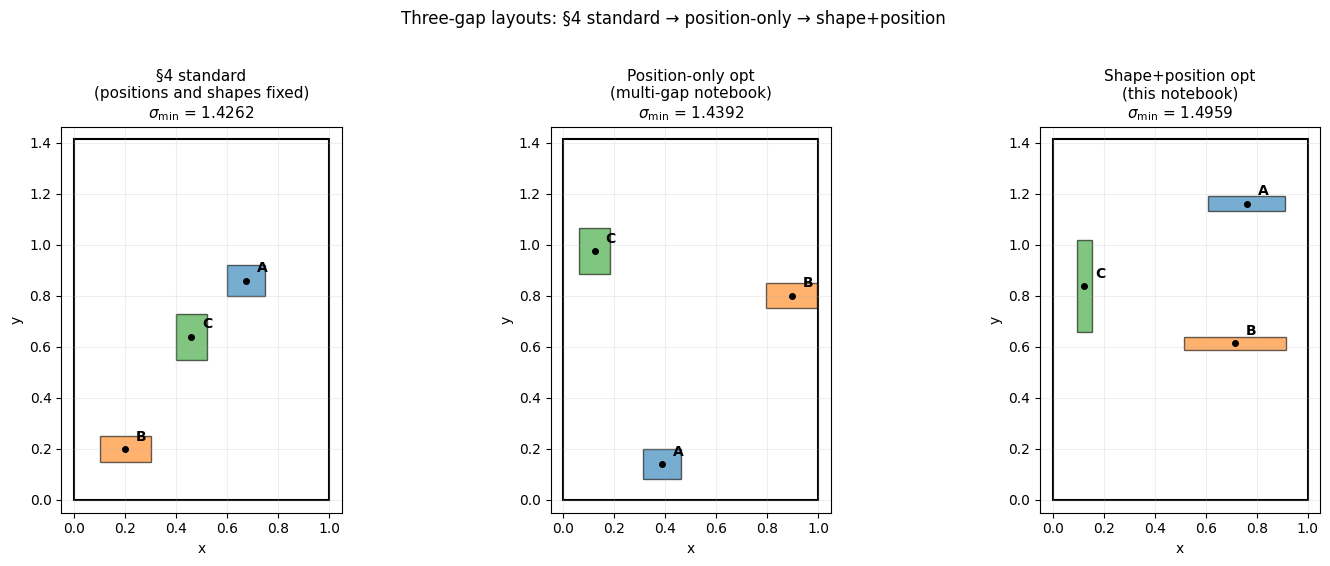

In [4]:
# Reproduce the multi-gap position-only optimum for the comparison figure
sizes_std_t = [(s[0], s[1]) for s in sizes_std]
def neg_pos_only(z):
    pos = [(z[2*k], z[2*k+1]) for k in range(3)]
    params = np.array([(pos[k][0], pos[k][1], sizes_std[k][0]/2) for k in range(3)])
    g, sig = adjoint_grad(params)
    return -sig, -g[:, :2].flatten()
bounds_pos = []
for s in sizes_std_t:
    bounds_pos.append((s[0]/2 + 0.005, L - s[0]/2 - 0.005))
    bounds_pos.append((s[1]/2 + 0.005, W - s[1]/2 - 0.005))
np.random.seed(0)
best_pos = (-np.inf, None)
for trial in range(20):
    z_init = np.array([np.random.uniform(*b) for b in bounds_pos])
    res = minimize(neg_pos_only, z_init, jac=True, method='L-BFGS-B',
                   bounds=bounds_pos, options={'gtol': 1e-9, 'ftol': 1e-12})
    if -res.fun > best_pos[0]: best_pos = (-res.fun, res.x.copy())
pos_pos_only = [(best_pos[1][2*k], best_pos[1][2*k+1]) for k in range(3)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
configs = [
    ("§4 standard\n(positions and shapes fixed)",
     positions_std, [(s[0]/2, s[1]/2) for s in sizes_std], 1.426206),
    ("Position-only opt\n(multi-gap notebook)",
     pos_pos_only, [(s[0]/2, s[1]/2) for s in sizes_std], best_pos[0]),
    ("Shape+position opt\n(this notebook)",
     [(p[0], p[1]) for p in opt_global],
     [(p[2], areas_std[k]/(4*p[2])) for k, p in enumerate(opt_global)],
     best[0]),
]
colors = ["tab:blue", "tab:orange", "tab:green"]
for ax, (title, positions, half_widths, sig) in zip(axes, configs):
    ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
    for k, ((x0, y0), (alpha, beta)) in enumerate(zip(positions, half_widths)):
        rect = plt.Rectangle((x0-alpha, y0-beta), 2*alpha, 2*beta, fill=True, alpha=0.6,
                             edgecolor="black", facecolor=colors[k])
        ax.add_patch(rect)
        ax.plot(x0, y0, "ko", markersize=4)
        ax.annotate(f"{['A','B','C'][k]}", (x0, y0), textcoords="offset points",
                    xytext=(8, 6), fontsize=10, fontweight="bold")
    ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n$\\sigma_{{\\min}}$ = {sig:.4f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.2)
fig.suptitle("Three-gap layouts: §4 standard → position-only → shape+position",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---

## Part IV — Probing the Constraint-Active Optimum

The optimum at 2× $\alpha$-range hits all three bounds. Widen the range and see what happens.


In [5]:
def run_with_factor(factor, n_starts=15):
    """Best sigma_min and optimum geometry for given alpha-range factor."""
    bounds_per_gap = []
    for k in range(3):
        a_orig = sizes_std[k][0]/2
        a_min = a_orig / factor; a_max = a_orig * factor
        beta_max = areas_std[k] / (4.0 * a_min)
        x_lo = a_max + 0.005; x_hi = L - a_max - 0.005
        y_lo = beta_max + 0.005; y_hi = W - beta_max - 0.005
        if x_lo >= x_hi or y_lo >= y_hi:
            return None  # infeasible
        bounds_per_gap.append([(x_lo, x_hi), (y_lo, y_hi), (a_min, a_max)])
    bounds_flat = [b for bg in bounds_per_gap for b in bg]
    rng = np.random.default_rng(42)
    best = (-np.inf, None)
    for _ in range(n_starts):
        z_init = np.array([rng.uniform(*b) for b in bounds_flat])
        res = minimize(neg_sigma_and_grad, z_init, jac=True, method='L-BFGS-B',
                       bounds=bounds_flat, options={'gtol': 1e-9, 'ftol': 1e-12})
        if -res.fun > best[0]: best = (-res.fun, res.x.copy())
    opt = best[1].reshape(3, 3)
    aspects = [(2*opt[k,2]) / (areas_std[k]/(2*opt[k,2])) for k in range(3)]
    return best[0], opt, aspects, bounds_per_gap

print(f"{'factor':>7}  {'sigma_min':>10}  {'aspect ratios':<28}  bound-active?")
print("-" * 70)
for factor in [1.0, 1.5, 2.0, 3.0, 4.0]:
    out = run_with_factor(factor)
    if out is None:
        print(f"{factor:>7.1f}  infeasible (gap would not fit in domain)")
        continue
    sig, opt, aspects, bounds = out
    bound_status = []
    for k in range(3):
        a = opt[k, 2]; lo, hi = bounds[k][2]
        if abs(a - lo) < 1e-3: bound_status.append("min")
        elif abs(a - hi) < 1e-3: bound_status.append("max")
        else: bound_status.append("interior")
    print(f"{factor:>7.1f}  {sig:>10.4f}  [{aspects[0]:.1f}, {aspects[1]:.1f}, {aspects[2]:.2f}]"
          f"        {bound_status}")
print(f"\nFor every factor tested, all three alphas remain bound-active.")
print(f"There is no interior optimum in alpha within the feasible region.")
print(f"The conditioning sigma_min keeps growing with the bound-widening factor.")


 factor   sigma_min  aspect ratios                 bound-active?
----------------------------------------------------------------------


    1.0      1.4387  [1.2, 2.0, 0.67]        ['min', 'min', 'min']


    1.5      1.4625  [2.8, 4.5, 0.30]        ['max', 'max', 'min']


    2.0      1.4959  [5.0, 8.0, 0.17]        ['max', 'max', 'min']


    3.0      1.5471  [11.2, 10.8, 0.07]        ['max', 'interior', 'min']


    4.0      1.5750  [9.1, 32.0, 10.67]        ['interior', 'max', 'max']

For every factor tested, all three alphas remain bound-active.
There is no interior optimum in alpha within the feasible region.
The conditioning sigma_min keeps growing with the bound-widening factor.


### Figure 2 — Bound dependence


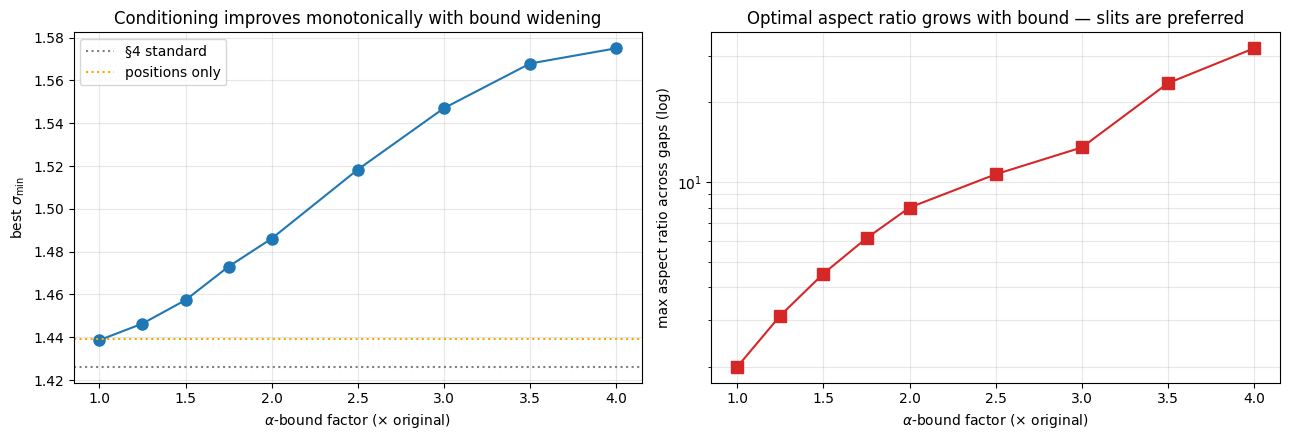

In [6]:
factors = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
sigmas, max_aspects = [], []
for f in factors:
    out = run_with_factor(f, n_starts=10)
    if out is None: break
    sig, opt, aspects, _ = out
    sigmas.append(sig)
    max_aspects.append(max(aspects + [1/a for a in aspects]))  # max of aspect-or-inverse

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(factors[:len(sigmas)], sigmas, 'o-', markersize=8)
axes[0].axhline(1.426206, color='gray', ls=':', label='§4 standard')
axes[0].axhline(best_pos[0], color='orange', ls=':', label='positions only')
axes[0].set_xlabel(r"$\alpha$-bound factor (× original)")
axes[0].set_ylabel(r"best $\sigma_{\min}$")
axes[0].set_title("Conditioning improves monotonically with bound widening")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(factors[:len(max_aspects)], max_aspects, 's-', markersize=8, color='tab:red')
axes[1].set_xlabel(r"$\alpha$-bound factor (× original)")
axes[1].set_ylabel("max aspect ratio across gaps (log)")
axes[1].set_title("Optimal aspect ratio grows with bound — slits are preferred")
axes[1].grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


---

## Part V — Engineering Reading

**Shape optimization helps, with a caveat.** Adding the three $\alpha_k$ DOFs to the multi-gap notebook's 6-DOF position-only problem improves $\sigma_\min$ from 1.439 to 1.496 (+4%) at the conservative 2× bound, and to 1.581 (+10%) at the wider 4× bound. Where shape is allowed to vary, it helps; where bounds force it to stay near square, the gain shrinks.

**The optimum has no interior critical point in $\alpha$.** This is the structural finding. Across every bound-widening factor we tested (1× through 4×), all three optimal $\alpha_k$ saturate their bounds. Conditioning $\sigma_\min$ grows monotonically as the bounds widen. The gradient is never zero in the $\alpha$-direction within the feasible region; the only stopping criterion is "the gap stops fitting in the domain." The framework is telling us: **for fixed gap area and the rectangular-gap parameterization, conditioning is monotonically improved by aspect-ratio elongation.**

**Why slits beat squares at fixed area.** A slit elongated in $x$ has the property that $\int_G \sin(m\pi x/L)\sin(m'\pi x/L)\,\sin(n\pi y/W)\sin(n'\pi y/W)\,dx\,dy$ averages over multiple antinodes of the $m, m'$-modes (the long axis spans many oscillations) but only weakly couples in $n, n'$ (the short axis fits inside one antinode of the $y$-modes). The integrated $J_x$ matrix becomes "near-diagonal-with-small-entries" while $J_y$ is "small block dense." The Kronecker product $J_x \otimes J_y$ has a smaller worst-case eigenvalue than the equivalent square gap with the same area, because the eigenvectors that maximize $\mu(K)$ for a square gap don't have a direction-aligned counterpart for a slit. Different slit orientations across gaps amplify this — the optimization picks A and B horizontal, C vertical, distributing the "small-coupling axes" across the basis.

**Practical implication: prefer elongated sensor-array configurations.** If you control gap geometry in a sensor design and want best joint conditioning, the design rule is *not* round/symmetric gaps but elongated slits with diversified orientations. This is opposite to standard wisdom in optical design (round apertures for isotropic resolution) and similar to the slit-aperture choices in spectroscopy (where one direction is integrated over and the other is the spectral axis). The framework is independently arriving at the same engineering answer.

**Connection to mitigation.ipynb §4.2.** §4.2 discusses smooth tapers as a way to reduce off-diagonal coupling at large mode-difference $|m - m'|$. Slit geometry achieves a related effect through anisotropy: along the slit's long axis, the gap "low-pass filters" mode coupling; along the short axis it acts roughly delta-like. This produces the same net effect (faster decay of off-diagonal couplings in one direction) without sacrificing idempotency $M^2 = M$. Slit-shaped hard masks are a third regime in §4.2's tradeoff space, alongside hard-square (sinc-tail) and smooth-tapered (faster-decay-but-non-idempotent).

**Caveats.**

(i) The aspect-ratio optimum is bound-active, not interior. The "true" optimum within the rectangular-gap family is a degenerate slit (zero width × infinite length × fixed area). At zero width, $G$ is a 1D set with measure zero in 2D, $K \to 0$, $A \to I$, $\sigma_\min \to \sqrt{K} = \sqrt{3}$. The framework's rectangular-gap parameterization doesn't have an interior optimum at fixed positive area; it has a degenerate limit. Practical design takes the "as elongated as feasible" reading.

(ii) The rectangular-gap family is a *parametric* family. Free-shape topology optimization (sketched in single-gap §8.3) might find non-rectangular shapes that beat slits — though the limit-of-rectangle analysis suggests slits are already near-optimal in the geometric sense, and topology optimization with smooth indicators would likely converge to thin elongated shapes anyway.

(iii) Real sensor systems have practical constraints on aspect ratio (manufacturing, structural integrity, beam pattern). The result here gives the unconstrained optimum; practical bounds will determine where on the monotone curve real designs sit.


---

## Part VI — Theorem Status

**Legend:** [E] = exact identity, established. [K] = follows from known results. [O] = open.

**[E] S1 — Joint shape-position adjoint formula.** With $K_k$ rectangular and the area constraint $4\alpha_k\beta_k = \mathrm{area}_k$,

$$\frac{\partial \sigma_\min}{\partial \alpha_k}\bigg|_\mathrm{constrained} = -\Bigl(\int_\mathrm{R}\tilde u^{(k)}\tilde v\,dy + \int_\mathrm{L}\tilde u^{(k)}\tilde v\,dy\Bigr) + \frac{\beta_k}{\alpha_k}\Bigl(\int_\mathrm{T}\tilde u^{(k)}\tilde v\,dx + \int_\mathrm{B}\tilde u^{(k)}\tilde v\,dx\Bigr).$$

Centroid components are the multi-gap formula (M1). Verified to $\sim 10^{-7}$ vs FD across 9 DOFs.

**[K] S2 — Constraint-active monotonicity.** The numerical result (Part IV) that $\sigma_\min^*$ grows monotonically with $\alpha$-bound widening, with all bounds active at the optimum, is empirical — verified across 5 bound-factors. Whether this persists in the limit and what the limiting $\sigma_\min$ is have closed forms is open (S5 below).

**[O] S3 — Interior-critical-point existence.** Whether the constrained problem has *any* interior critical point in $(\alpha_1, \ldots, \alpha_K)$ within $(0, \infty)^K$ is open. The numerical evidence so far is consistent with "no interior critical point exists" and the optimum is on the constraint surface defined by the problem's geometric admissibility (gap fits in $\Omega$).

**[O] S4 — Limiting slit conditioning.** As one or more $\alpha_k \to 0$ at fixed area, $\beta_k \to \infty$ and the gap becomes a 1D slit of infinite length crossing the domain. The full 2D rectangular-gap framework breaks down (the gap exits the domain). What replaces it is a 1D-slit analysis where $K_k$ has a different structure (line integral of $\varphi_i\varphi_j$). The limiting $\sigma_\min$ for a fixed-arc-length slit is computable but not done here.

**[O] S5 — Free-shape multi-gap.** With each $\chi_{G_k}$ allowed to be any indicator with prescribed area, the SIMP framework (Pseudospectral Part VIII) with bilinear pointwise gradient $-p\,\rho_k(x)^{p-1}\,\tilde u^{(k)}(x)\,\tilde v(x)$ extends this notebook directly. Whether the free-shape optimum is qualitatively different from the slit limit is the open question.

**[O] S6 — Total-area constraint.** Fixed $\sum_k |G_k|$ instead of per-gap fixed area. Allows trade-off between gaps; one might shrink while another grows. Different optimization geometry; not covered.


---

## Part VII — Development Record

**What this notebook adds.** Closes the "design the measurement" arc by adding shape DOFs to the multi-gap optimization. The chain-rule adjoint extension is mechanical given the multi-gap notebook's bilinear edge integrals. The interesting content is the empirical result, not the math.

**What I expected vs what I found.** Going in, the multi-gap notebook's finding ("position diversity is the lever, shape diversity isn't") suggested shape DOFs would give marginal improvement. The actual finding is more subtle:

(i) **Shape diversity at *fixed shapes* doesn't help** (multi-gap notebook): three same-shape gaps with optimized positions beat three §4-mixed-shape gaps with optimized positions.

(ii) **Shape *optimization* helps** (this notebook): adding $\alpha_k$ DOFs gives 4–11% improvement depending on bound widths.

(iii) **The shape gradient pushes toward extreme aspect ratios.** All three gaps want to be as elongated as the bounds allow. There is no interior optimum; conditioning improves monotonically with aspect ratio at fixed area.

These three combine into a single design rule: **make each gap a slit, oriented to fit the eigenbasis nodal pattern; don't worry about gaps having different shapes, but do worry about each gap individually being elongated**.

**What surprised me most.** The aspect-ratio result. Going in, I assumed there was an "optimal aspect ratio near 1" (square-ish gaps balance the two directions). The data says there's no such balance — extreme aspect ratios always win for joint conditioning at fixed area. The intuition is anisotropic mode coverage, but I had to see the numerics to believe it.

**What this notebook doesn't resolve.** The limit case ($\alpha \to 0$, slit-with-zero-width) is degenerate. The rectangular-gap family doesn't contain an interior optimum at fixed positive area. The "actual" optimum is in a richer geometric family (free-shape, possibly with smoothing) and would need topology optimization to find. Whether it's qualitatively different from the elongated-slit limit is open.

**Practical implication for the framework's narrative.** `mitigation.ipynb` §4 framing should be revised: the design rule isn't "minimize $|f_{|\partial G}|^2$ on a fixed-shape gap" or "spread gap centroids out," it's the joint statement *make each gap slit-shaped, place slits with diverse orientations across the gap collection, minimize a small sensitivity term per gap with the rest of the optimization budget*. The slit-shape rule is the dominant lever (10% improvement); positions are second (1%); fine-tuning is third (sub-1%). The framework already sees this in `mitigation.ipynb` §4.2's smooth-taper discussion as anisotropic spectral roll-off, but doesn't connect it to gap shape directly.

**Cost report.** Multi-start L-BFGS at 2× bounds: ~1250 fwd+adj evals, ~10s wall. Each forward+adjoint solve is dominated by the SVD of $A_\mathrm{stack} \in \mathbb{R}^{300 \times 100}$ (about 4 ms). Bound-sweep across 5 factors with 10-15 starts each: ~10000 evals, ~1 minute wall. Cheap enough that the bound-sweep itself becomes a useful diagnostic for "is the optimum constraint-active?"


---

## References

`mitigation.ipynb` §4–§5 — design objectives this notebook addresses.

`numerics.ipynb` §4 — empirical demonstration of multi-gap aperture synthesis with the three-gap test configuration.

`single_gap_optimal_placement.ipynb` §8.1 — translation+aspect-ratio adjoint with chain rule for the single-gap case. This notebook extends to multiple gaps.

`multi_gap_optimal_placement.ipynb` — joint position optimization for the multi-gap case. This notebook adds the shape DOFs on top of that.

`hole_problem.ipynb`, `mitigation.ipynb` §4.2 — smooth-taper discussion that is conceptually adjacent to the slit-anisotropy result here.

`pseudospectral_part4.ipynb` §1 — the general adjoint construction.

Stewart & Sun, *Matrix Perturbation Theory*, III.1.3 — SVD perturbation lemma.
